In [68]:
from bitarray import bitarray
import hashlib
from hashlib import sha3_256, sha256, blake2b
import math 
import mmh3
import string
import json
import requests
import plotnine as p9
from plotnine import ggplot, aes, geom_line, labs, theme_minimal, guide_legend, scale_x_log10
import pandas as pd

In [ ]:
# You can read the list one at a time using the code snippet below

words = []

with open('words.txt') as f:
    for line in f:
        word = line.strip().lower()
        words.append(word)

In [27]:
from hashlib import sha3_256, sha256, blake2b
# everyting  below is done with 10_000_000 size bitarray

size = 10_000_000
def my_hash(s):
    return int(sha256(s.lower().encode()).hexdigest(), 16) % size # given
def my_hash2(s):
    return int(blake2b(s.lower().encode()).hexdigest(), 16) % size
def my_hash3(s):
    return int(sha3_256(s.lower().encode()).hexdigest(), 16) % size

three_hash_functions = [my_hash, my_hash2, my_hash3] # set functions that will later dictate how many hashes are used
two_hash_functions = [my_hash, my_hash2]
one_hash_function = [my_hash]

In [28]:
from bitarray import bitarray

class BloomFilter:
    def __init__(self, size, hash_functions):
        self.size = size
        self.hash_functions = hash_functions
        self.bit_array = bitarray(self.size)
        self.bit_array.setall(0)

    def add(self, item):
        for func in self.hash_functions:
            index = func(item)
            if index >= self.size: # sanity check for index and hash size
                raise ValueError(f"Index {index} out of bounds for size {self.size}")
            self.bit_array[index] = 1

    def check(self, item):
        for func in self.hash_functions:
            index = func(item)
            if self.bit_array[index] == 0:
                return False
        return True


In [29]:
bloomf_3 = BloomFilter(size,three_hash_functions) # added words to bloom filter using size given and all three hashed
bloomf_2 = BloomFilter(size, two_hash_functions) # two hashes used
bloomf_1 = BloomFilter(size, one_hash_function) # one hash used
bloom_test = BloomFilter(size, three_hash_functions)

for word in words: # added words to each type of bloom filter
    bloomf_3.add(word)
    bloomf_2.add(word)
    bloomf_1.add(word)

bloom_test.add("apple")
bloom_test.add("banana")

In [30]:
print(bloom_test.check("apple"))
print(bloomf_3.check('abandoner'))
print(bloomf_3.check('carolinejkerwe'))

True
True
False


In [31]:
#b. Create a function that checks all possible single-character substitutions for a given word using the Bloom filter. . 

#I need the function to take in each word, replace a single character, compare to the rest of list and return if it is a match. Repeat for all letter combinations

#Asked ChatGPT how to make a function that replces single character in given word
def single_char_changes(word): 
    replaced_words = []
    for i in range(len(word)):
        for letter in string.ascii_lowercase:
            if word[i] != letter:
                changed = word[:i] + letter + word[i+1:]
                replaced_words.append(changed)
    return replaced_words

#Tested that the function does single character substitution for word given
len(single_char_changes('cat'))

75

In [32]:
#create full function
#Asked ChatGPT how to compare again the bloom filter and ensure function is doing what i want. 
def spell_check(word, bloom):
    candidates = single_char_changes(word)
    matches = []
    for candidate in candidates:
        if bloom.check(candidate): #check  if hash function is there 
            matches.append(candidate)
    return matches


In [33]:
spell_check('bpple', bloom_test)

['apple']

In [34]:
spell_check('floeer', bloomf_1)

['bloeer',
 'qloeer',
 'fyoeer',
 'flofer',
 'floter',
 'flower',
 'floeqr',
 'floees']

In [35]:
spell_check('floeer', bloomf_2)

['fyoeer', 'floter', 'flower']

In [36]:
spell_check('floeer', bloomf_3)

['floter', 'flower']

In [37]:
#call in typos and visualize
with open('typos.json', 'r') as file2:
    typos = json.load(file2)

for typed_word, correct_word in typos:
    typed_word.lower().strip()
    correct_word.lower().strip()

In [38]:
print(typos[:5])

[['soprabi', 'soprani'], ['rosan', 'rosan'], ['jeresiologer', 'heresiologer'], ['wrinkvy', 'wrinkly'], ['seaweeds', 'seaweeds']]


In [56]:
def good_bloom(typed_word, correct_word, bloom):
    good_suggestion = 0
    misidentified = 0
    total_checked   = 0
    if typed_word == correct_word: #if typo and correct word are same, returns 
        return good_suggestion, misidentified, total_checked
    
    suggestions = spell_check(typed_word, bloom) # does single character changes and returns any that are in bloom filter
    total_checked += 1 # if typo and correct word are not same, adds 1 total checked

    # check if it's a good suggestion
    if len(suggestions) <= 3 and correct_word in suggestions: # is matches is more than 3, deems it a bad outcome. If matches is less than 3 deems it a good outcome; need to add if it includes correct word is good, if not is bad. 
        good_suggestion += 1 # if less than 3 and has correct word counts 1 to good suggestions
    # Count misidentified
    else:
        misidentified += 1 # else counts one to misidentified 
    
    return good_suggestion, misidentified, total_checked # returns number of good suggestions, misidentified, and total checked
    

In [40]:
print(good_bloom('floeer', 'flower', bloomf_1))
print(good_bloom('floeer', 'flower', bloomf_2))
print(good_bloom('floeer', 'flower', bloomf_3))
print(good_bloom('flower', 'flower', bloomf_3))

(0, 1, 1)
(1, 0, 1)
(1, 0, 1)
(0, 0, 0)


In [46]:
# Cycle through typos and implement good blom and keep track of counts
# one hash with 10_000_000 bit array

total_good_suggestions = 0
total_misidentified = 0
total_checked = 0

for typed_word, correct_word in typos:
    bloom = bloomf_1
    good, misidentified, checked = good_bloom(typed_word, correct_word, bloom)
    total_good_suggestions += good
    total_misidentified += misidentified
    total_checked += checked

print(total_good_suggestions, total_misidentified, total_checked)
print(f"Preformance at 1 hash 10,000,000 bits was {(total_good_suggestions/total_checked)*100}% good suggestions and {(total_misidentified/total_checked)*100}% misidentified")
#so using a 10_000_000 bit, bloom 1 had a good suggestion 120/250000 and misidentified of 24880/25000


40 24960 25000
Preformance at 1 hash 10,000,000 bits was 0.16% good suggestions and 99.83999999999999% misidentified


In [ ]:
# Cycle through typos and implement good blom and keep track of counts
# two hash with 10_000_000 bit array

total_good_suggestions = 0
total_misidentified = 0
total_checked = 0

for typed_word, correct_word in typos:
    bloom = bloomf_2
    good, misidentified, checked = good_bloom(typed_word, correct_word, bloom)
    total_good_suggestions += good
    total_misidentified += misidentified
    total_checked += checked

print(total_good_suggestions, total_misidentified, total_checked)
print(f"Preformance at 2 hash 10,000,000 bits was {(total_good_suggestions/total_checked)*100}% good suggestions and {(total_misidentified/total_checked)*100}% misidentified")
#so using a 10_000_000 bit, bloom 2 had a good suggestion 120/250000 and misidentified of 24880/25000


15654 9346 25000
Preformance at 2 hash 10,000,000 bits was 0.62616 good suggestions and 0.37384 misidentified


In [ ]:
# Cycle through typos and implement good blom and keep track of counts
# three hash with 10_000_000 bit array

total_good_suggestions = 0
total_misidentified = 0
total_checked = 0

for typed_word, correct_word in typos:
    bloom = bloomf_3
    good, misidentified, checked = good_bloom(typed_word, correct_word, bloom)
    total_good_suggestions += good
    total_misidentified += misidentified
    total_checked += checked

print(total_good_suggestions, total_misidentified, total_checked)
print(f"Preformance at 3 hash 10,000,000 bits was {(total_good_suggestions/total_checked)*100}% good suggestions and {(total_misidentified/total_checked)*100}% misidentified")
#so using a 10_000_000 bit, bloom 1 had a good suggestion 120/250000 and misidentified of 24880/25000


22946 2054 25000
Preformance at 3 hash 10,000,000 bits was 0.91784 good suggestions and 0.08216 misidentified


In [44]:
def my_hash_factory(size):
    def my_hash(s):
        return int(sha256(s.lower().encode()).hexdigest(), 16) % size
    return my_hash

def my_hash2_factory(size):
    def my_hash2(s):
        return int(blake2b(s.lower().encode()).hexdigest(), 16) % size
    return my_hash2

def my_hash3_factory(size):
    def my_hash3(s):
        return int(sha3_256(s.lower().encode()).hexdigest(), 16) % size
    return my_hash3

In [ ]:
sizes = [100_000, 500_000, 1_000_000, 1_500_00, 10_000_000, 50_000_000, 100_000_000, 500_000_000, 1_000_000_000, 5_000_000_000, 10_000_000_000] # ran and plotted for 10^2-10^8 as in given graph
bloom_filters = {}

for size in sizes:
    # Create hash functions with size fixed
    h1 = my_hash_factory(size)
    h2 = my_hash2_factory(size)
    h3 = my_hash3_factory(size)

    # Store Bloom filters with descriptive keys
    bloom_filters[(size, 1)] = BloomFilter(size, [h1])
    bloom_filters[(size, 2)] = BloomFilter(size, [h1, h2])
    bloom_filters[(size, 3)] = BloomFilter(size, [h1, h2, h3])

print(len(bloom_filters))

for bf in bloom_filters.values():
    for word in words:
        bf.add(word)

21


In [ ]:
def debug_check(item, bloom): # implemented check to ensure bloom filters created correctly and got false positive. ChatGPT suggested this debugging to ensure it was false positive and my bloom filter was in fact working correctly
    for func in bloom.hash_functions:
        index = func(item)
        print(f"Checking bit at index {index} -> {bloom.bit_array[index]}")
        if bloom.bit_array[index] == 0:
            return False
    return True

debug_check('flowersskldjf', bloom_filters[(1_000_000, 3)])


Checking bit at index 757444 -> 0


False

In [ ]:
print(good_bloom('floeer', 'flower', bloom_filters[(10_000_000, 1)])) # tested 'floeer' again on new bloom filters. confirmed loaded correctly bc got the same results as above 
print(good_bloom('floeer', 'flower', bloom_filters[(10_000_000, 2)]))
print(good_bloom('floeer', 'flower', bloom_filters[(10_000_000, 3)]))
print(good_bloom('flower', 'flower', bloom_filters[(10_000_000, 1)]))

(0, 1, 1)
(1, 0, 1)
(1, 0, 1)
(0, 0, 0)


In [63]:
# Dictionary to store results for each (size, num_hashes)
results = {}

for (size, num_hashes), bloom in bloom_filters.items(): # cycles through all 21 hashes in bloom filters dictionary
    total_good_suggestions = 0
    total_misidentified = 0
    total_checked = 0

    for typed_word, correct_word in typos: # in individual bloom filter, for typed, correct word in types
        good, misidentified, checked = good_bloom(typed_word, correct_word, bloom) # implements good bloom and saves answers to these variables 
        total_good_suggestions += good
        total_misidentified += misidentified
        total_checked += checked

    # Save results in a dictionary for later analysis or plotting
    results[(size, num_hashes)] = {
        "good": total_good_suggestions,
        "misidentified": total_misidentified,
        "total checked": total_checked,
        "good_pct": (total_good_suggestions / total_checked) * 100 if total_checked else 0,
        "misidentified_pct": (total_misidentified / total_checked) * 100 if total_checked else 0
    }

    # Print summary
    print(f"Results for size={size}, hashes={num_hashes}")
    print(f"  Good: {total_good_suggestions}, Misidentified: {total_misidentified}, Checked: {total_checked}")
    print(f"  Good suggestions: {results[(size, num_hashes)]['good_pct']:.2f}%, Misidentified: {results[(size, num_hashes)]['misidentified_pct']:.2f}%")
    print('-' * 60)


Results for size=1000, hashes=1
  Good: 0, Misidentified: 25000, Checked: 25000
  Good suggestions: 0.00%, Misidentified: 100.00%
------------------------------------------------------------
Results for size=1000, hashes=2
  Good: 0, Misidentified: 25000, Checked: 25000
  Good suggestions: 0.00%, Misidentified: 100.00%
------------------------------------------------------------
Results for size=1000, hashes=3
  Good: 0, Misidentified: 25000, Checked: 25000
  Good suggestions: 0.00%, Misidentified: 100.00%
------------------------------------------------------------
Results for size=10000, hashes=1
  Good: 0, Misidentified: 25000, Checked: 25000
  Good suggestions: 0.00%, Misidentified: 100.00%
------------------------------------------------------------
Results for size=10000, hashes=2
  Good: 0, Misidentified: 25000, Checked: 25000
  Good suggestions: 0.00%, Misidentified: 100.00%
------------------------------------------------------------
Results for size=10000, hashes=3
  Good: 0,

In [74]:
plot_data = []

for (size, num_hashes), data in results.items():
    plot_data.append({
        "size": size,
        "type": f"{num_hashes} hash - Good",
        "percentage": data["good_pct"]
    })
    plot_data.append({
        "size": size,
        "type": f"{num_hashes} hash - Misidentified",
        "percentage": data["misidentified_pct"]
    })

df_plot = pd.DataFrame(plot_data)


In [75]:
# visualize head of dataframe to ensure added in correctly and tail to ensure all ran and results are as expected 
print(df_plot.head())
print(df_plot.tail())

   size                    type  percentage
0  1000           1 hash - Good         0.0
1  1000  1 hash - Misidentified       100.0
2  1000           2 hash - Good         0.0
3  1000  2 hash - Misidentified       100.0
4  1000           3 hash - Good         0.0
          size                    type  percentage
37  1000000000  1 hash - Misidentified       5.528
38  1000000000           2 hash - Good      94.808
39  1000000000  2 hash - Misidentified       5.192
40  1000000000           3 hash - Good      94.808
41  1000000000  3 hash - Misidentified       5.192


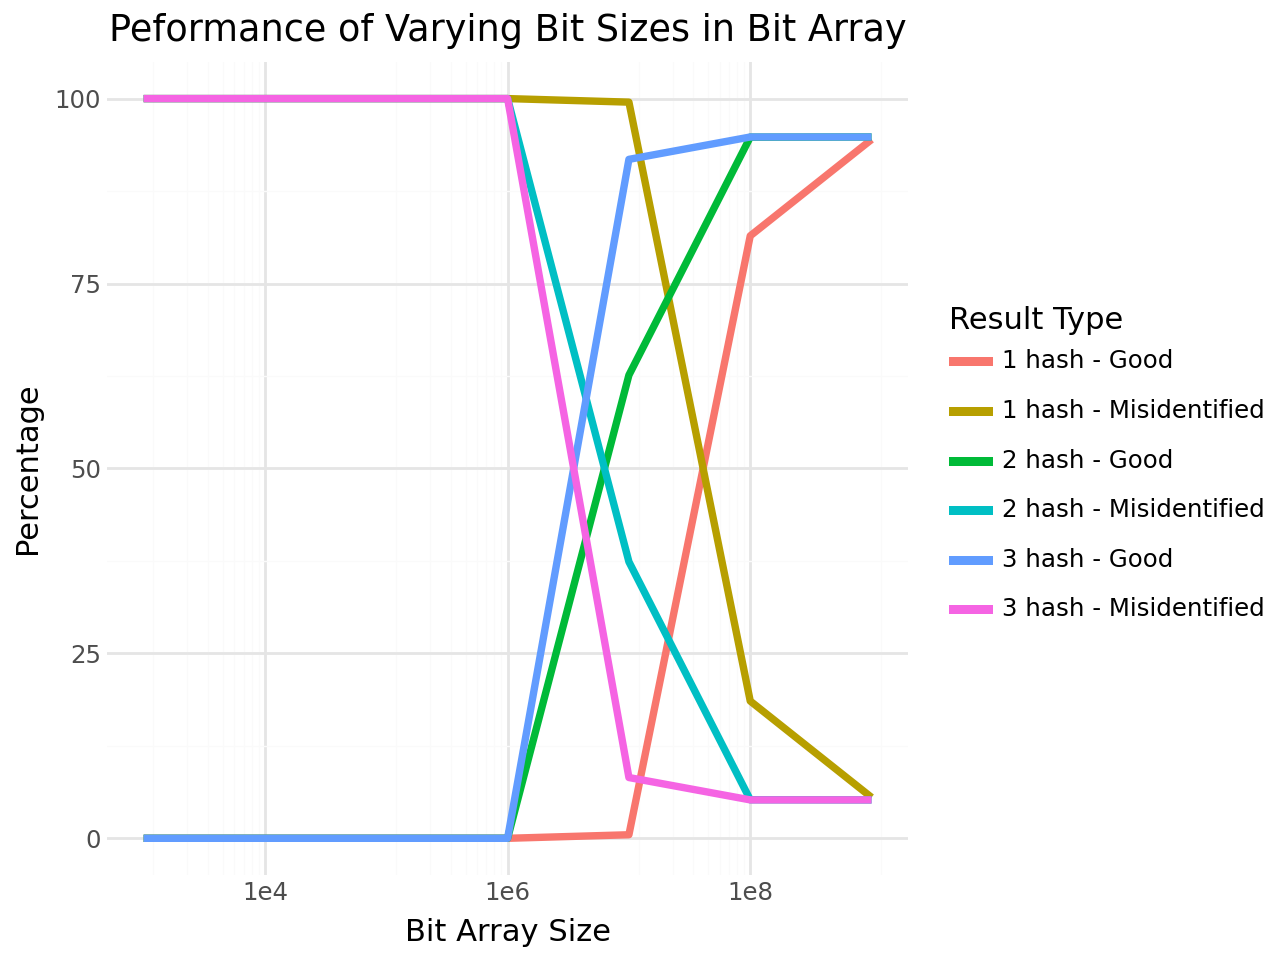

In [77]:
# from ChatGPT 
p = (
    ggplot(df_plot, aes(x='size', y='percentage', color='type'))
    + geom_line(size=1.5)
    + labs(
        title="Peformance of Varying Bit Sizes in Bit Array",
        x="Bit Array Size",
        y="Percentage",
        color="Result Type",
        linetype="Number of Hashes"
    )
    + theme_minimal()
    + scale_x_log10()  # Log scale for better spacing of sizes
)

p
